# Examine the set of 3-block light curves
"Bump" hunting. Isolate those with long start and end blocks, look for those
where the starting and ending fluxes are close.

In [14]:
%reset -f

from importlib import reload
from pylib import agn_steps; reload(agn_steps)
from pylib.agn_steps import (VarDB, set_theme, show_date,  association_breakdown, ThreeBlocks,
                             show, show_fig, np, pd, plt, hist_bbvar, capture_hide, lcsetup, bb_display)
from wtlike import WtLike
set_theme(['dark']); show_date()

<h5 style="text-align:right; margin-right:15px"> 2026-03-20 17:21</h5>

In [15]:
self =  ThreeBlocks(margin=700)
show(f'Associations for the {len(self.df)} three-block sources:')
show(association_breakdown(self.df))

<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0xf4b9ac37b380>

Associations for the 489 three-block sources:

,bll,fsrq,bcu,psr,other,unid
,132,45,146,18,13,135


In [16]:
self.df.width.apply(lambda x: sum(x)).describe()

count     489.000000
mean     6139.787321
std         2.213910
min      6139.000000
25%      6139.000000
50%      6139.000000
75%      6139.000000
max      6146.000000
Name: width, dtype: float64

## Bump flux property

<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0xf4b9b32541d0>
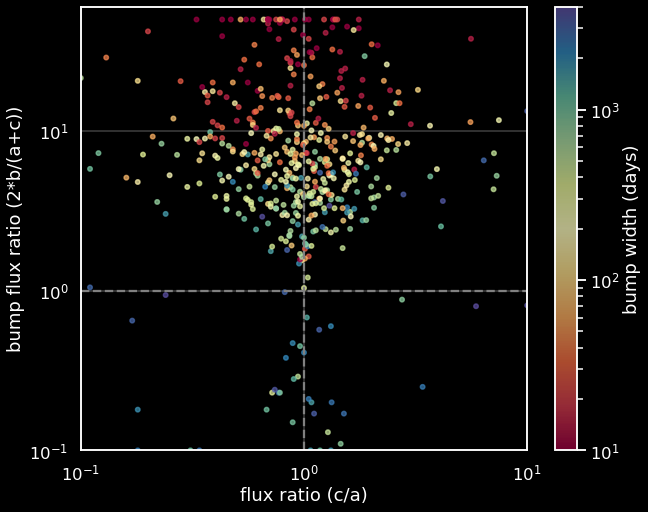

Notes:
* Most bumps are positive, flux ratio>2 or so 
* large bumps >10 are short--flares or from nearby flaring sources
* after/before flux ratio close to one
* The few negative bumps are long. 

In [17]:
show(f"""## Bump flux property""")
show_fig(self.bump_plot)
show("""\
Notes:
* Most bumps are positive, flux ratio>2 or so 
* large bumps >10 are short--flares or from nearby flaring sources
* after/before flux ratio close to one
* The few negative bumps are long. 
""")

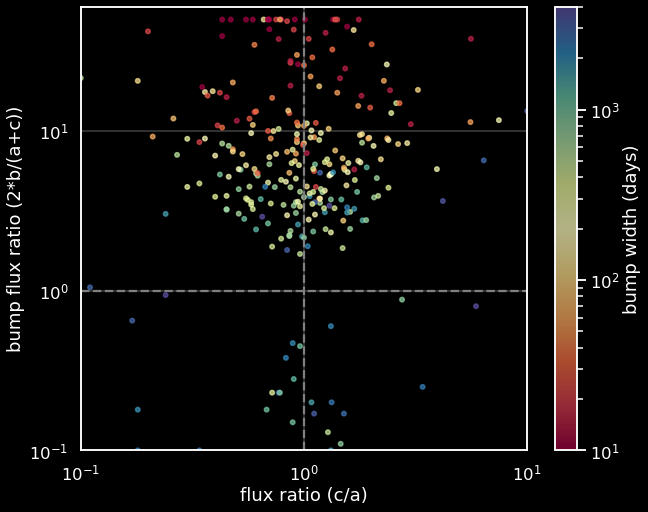

In [18]:
self.bump_plot('association in ["bll","bcu"]');

In [19]:
show(f""" Select sources with {(bump_cut:="2<bump_ratio<10 & 0.5<flux_ratio<2")}""")
df_bcut = self.df.query(bump_cut)
show(association_breakdown(df_bcut,'bump cut'))

Select sources with 2<bump_ratio<10 & 0.5<flux_ratio<2

,bll,fsrq,bcu,psr,other,unid
bump cut,68,16,60,6,7,58


In [20]:
df_bcut.query('association=="bll"').sort_values('ts', ascending=False)['ts bbvar variability flux_ratio bump_ratio bump_width'.split()]

,ts,bbvar,variability,flux_ratio,bump_ratio,bump_width
4FGL J0423.9+4150,3447,21,12.800000,1.13,4.47,21.0
4FGL J0844.9-5458,1999,27,20.900000,1.17,3.77,56.0
4FGL J1203.1+6031,1615,23,38.500000,1.11,5.62,28.0
4FGL J0847.0-2336,1334,21,36.400002,1.05,2.79,175.0
4FGL J1553.5-3118,1246,39,69.800003,1.25,2.43,476.0
...,...,...,...,...,...,...
4FGL J0502.5+1340,83,27,31.200001,1.12,6.19,903.0
4FGL J1042.9+0054,70,10,11.200000,0.67,4.48,2254.0
4FGL J1506.4+4331,56,23,12.800000,0.53,7.18,105.0
4FGL J1058.0+4305,54,31,31.100000,1.91,5.93,1260.0


In [21]:
# def lcsetup(name, **kwargs):
#     with capture_hide(f'Light curve setup for {name}') as cap:
#         wtl = WtLike(name, time_bins=(54682.5,60821.5,7), **kwargs)
#     show(cap)
#     return wtl 

<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0xf4b9b29277d0>

<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0xf4b9b3feafc0>

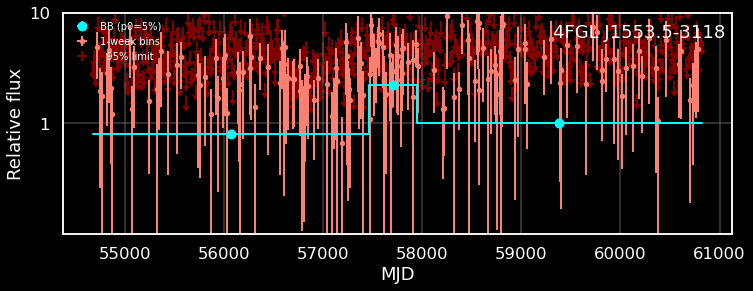

None

<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0xf4b9b40bb380>

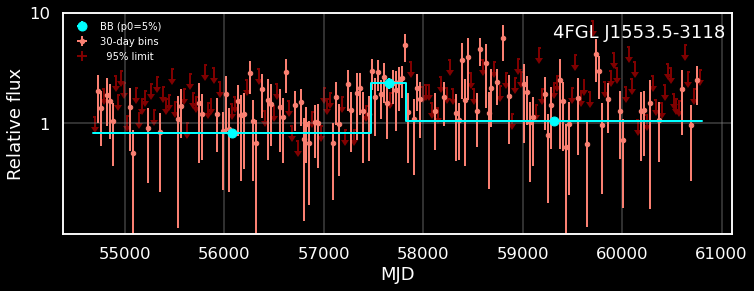

None

<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0xf4b9b215eed0>

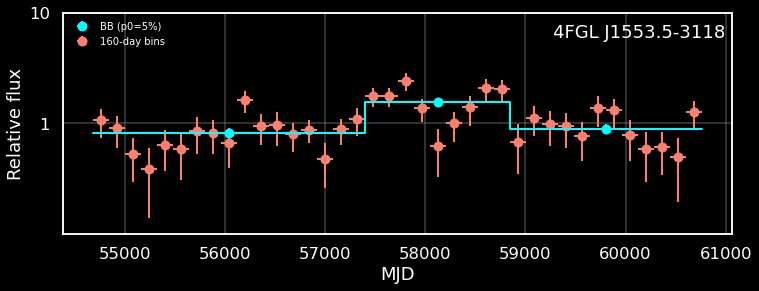

None

<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0xf4b9b495f770>

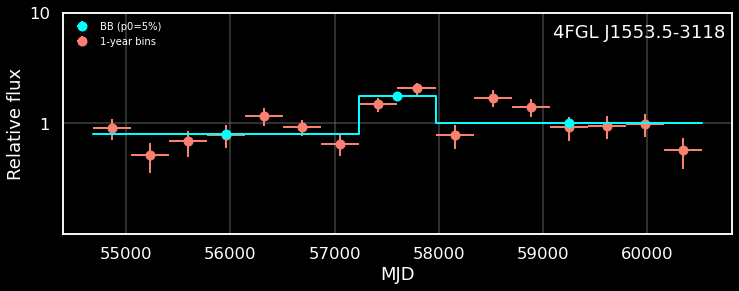

None

In [22]:
wtl = lcsetup('4FGL J1553.5-3118')  
for dt in 7, 30, 4*40, 365.25,:             
    bb = bb_display(wtl, dt); plt.show()
    show(bb)

In [23]:
show(bb)

None

In [24]:
def get_bb_info(bb):
    """ Return BB interval likelihood fits with 2-d (beta-free) fit also """
    
    def g2fit(cell):
        from wtlike.poisson import Poisson
        from wtlike.loglike import LogLike, Gaussian2dRep

        ts = Poisson.from_function(LogLike(cell)).ts
        r = dict(t=cell.t, tw=cell.tw, ts=round(ts,1))            
        if ts<4:
            r.update(flux=0, counts=cell.n, beta=np.nan, sig_beta=np.nan)
        else:
            r.update(Gaussian2dRep(LogLike(cell)).fit)
        return r
    try:
        df_bb = bb.fluxes['t tw ts flux errors'.split()]
        df_beta = pd.DataFrame.from_dict( 
            dict((i, g2fit(cell)) for i,cell in bb.cells.iterrows()) ,orient='index')\
                ['flux beta sig_beta'.split()]
        return pd.concat([df_bb, df_beta], axis=1)

    except Exception as e:
        import sys
        print(f'SourceAnalyzer: bb 2-d fit failed: {e}', file=sys.stderr)
        return None
    
with capture_hide():
    show(get_bb_info(bb))


SourceAnalyzer: bb 2-d fit failed: 'NoneType' object has no attribute 'fluxes'


None

<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0xf4b9b24081a0>

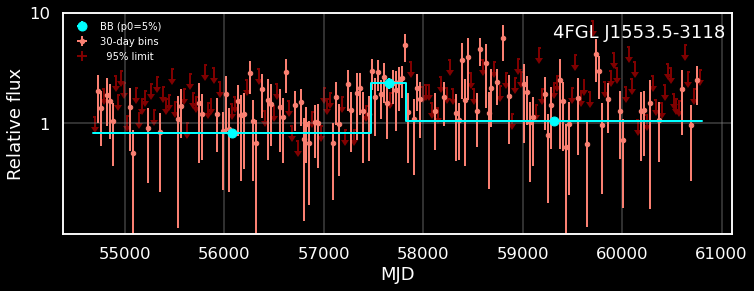

'<details >  <summary> 3 BB fits  </summary>  <div style="margin-left: 25px"><table border="1" class="dataframe">\n  <thead>\n    <tr style="text-align: right;">\n      <th>t</th>\n      <th>tw</th>\n      <th>ts</th>\n      <th>flux</th>\n      <th>errors</th>\n      <th>flux</th>\n      <th>beta</th>\n      <th>sig_beta</th>\n    </tr>\n  </thead>\n  <tbody>\n    <tr>\n      <td>56077.5</td>\n      <td>2790.0</td>\n      <td>395.4</td>\n      <td>0.8172</td>\n      <td>(-0.063, 0.064)</td>\n      <td>0.807027</td>\n      <td>0.003493</td>\n      <td>0.003008</td>\n    </tr>\n    <tr>\n      <td>57652.5</td>\n      <td>360.0</td>\n      <td>217.5</td>\n      <td>2.2979</td>\n      <td>(-0.254, 0.256)</td>\n      <td>2.249495</td>\n      <td>0.009295</td>\n      <td>0.008587</td>\n    </tr>\n    <tr>\n      <td>59317.5</td>\n      <td>2970.0</td>\n      <td>390.5</td>\n      <td>1.0469</td>\n      <td>(-0.079, 0.079)</td>\n      <td>1.068379</td>\n      <td>-0.005960</td>\n      <td>0.

In [25]:
def bb_display(wtl, bin_size=30, **kwargs):
    from utilities.ipynb_docgen import DataFrameWrapper
    kw = dict(log=True, ylim=(0.1,10)); kw.update(kwargs)
    with capture_hide(f'BB processing for {wtl.source_name}, bin size {bin_size}') as cap:
        bb = wtl.view(bin_size).bb_view()
        bb.plot(**kw)
    show(cap)
    plt.show()
    bt = get_bb_info(bb)
    if bt is None or len(bt)==0 or not 'beta' in bt : return ''
    test = np.max(bt.beta/bt.sig_beta)
    
    warning_text = f'<font color=red>Check beta:  max beta/sig_beta is {test:.1f}</font>' if test>2 else ''
    # with capture_hide(f'BB fits {warning_text}') as cp:
    #     print(bt)
    # return cp
    dw = DataFrameWrapper(bt, summary=f'{len(bt)} BB fits {warning_text}', index=False)
    return dw._repr_html_()
     
bb_display(wtl)

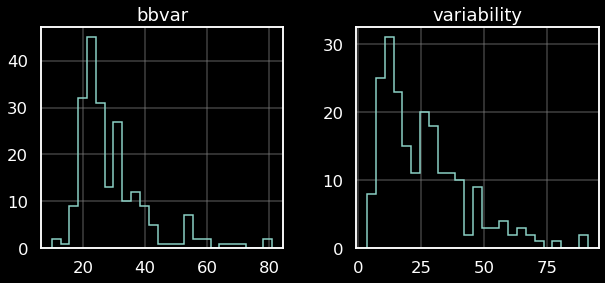

In [26]:
df_bcut.hist(['bbvar','variability'], bins=25, histtype='step', figsize=(10, 4)); plt.show()